# Step 1: Create Universe and Returns
This notebook loads the historical Yahoo Finance data and calculates the tradable universe based on Average Daily Volume (ADV) constraints, as well as the daily returns.

In [1]:
import pandas as pd
import os

DATA_DIR = "stores"
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('top_5000_yf_data.pkl')
print('Data loaded successfully.')

Loading top_5000_yf_data.pkl...
Data loaded successfully.


In [ ]:
# 1. Calculate Average Daily Volume (ADV) for trailing 60 days\n,
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=60).mean()
# 2. Price constraints
sum_abs_daily_change = df_historical['Close'].diff().abs().rolling(window=60, min_periods=60).sum()
er = net_change / sum_abs_daily_change
er_mask = er <= 0.5
# 4. Volatility >= median\n",
# Volatility as 60-day rolling std of daily returns\n",
daily_ret = df_historical['Close'].pct_change()
vol_60 = daily_ret.rolling(window=60, min_periods=60).std()
median_vol = vol_60.median(axis=1)
# Compare each stock's volatility to the cross-sectional median for that day\n",
vol_mask = vol_60.ge(median_vol, axis=0)

Universe shape: (4092, 4999)


<Axes: title={'center': 'Number of Tradable Stocks Over Time'}, xlabel='Date'>

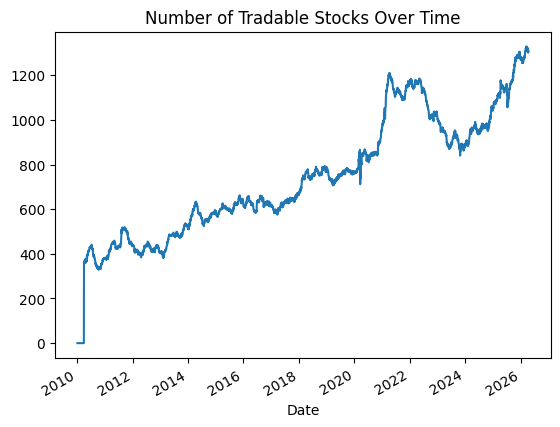

In [4]:
# Creating Universe based on all constraints
df_universe_5m = ((df_adv_60 >= 5_000_000) & price_mask & er_mask & vol_mask).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time")


In [5]:
# Saving 5M universe to stores folder
df_universe_5m.to_parquet(os.path.join(DATA_DIR, 'universe_5m.parquet'), engine='pyarrow')
print('Saved universe_5m.parquet')

Saved universe_5m.parquet


In [6]:
# Calculating returns for each ticker every day
# Using Adj Close to account for dividends and stock splits
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)

In [7]:
# Saving returns to parquet file
returns.to_parquet(os.path.join(DATA_DIR, 'returns.parquet'), engine='pyarrow')
print('Saved returns.parquet')

Saved returns.parquet
